# Odszumianie Sygnałów RF (I/Q) dla Celów Lokalizacji

Notatnik implementuje sieć neuronową w architekturze **1D U-Net DAE (Denoising Autoencoder)** służącą do filtracji szumu i zniekształceń wielodrogowych w sygnałach radiowych.

---

### 1. Format danych: SigMF (Signal Metadata Format)
Zarówno zbiór **ORACLE** (Wi-Fi 802.11a), jak i **AERPAW** (LTE/5G) wykorzystują otwarty standard **SigMF**:
* **Plik `.sigmf-meta`:** Plik JSON z metadanymi (częstotliwość nośna, częstotliwość próbkowania, typ danych, znaczniki czasu).
* **Plik `.sigmf-data`:** Czysty plik binarny zawierający naprzemienne próbki: $[I_0, Q_0, I_1, Q_1, \dots]$. Zazwyczaj zapisany jako `cf32_le` (zespolone float32, po 4 bajty na $I$ i $Q$) lub `ci16_le` (16-bitowe liczby całkowite).

---

### 2. Kształt tensorów w sieci neuronowej
Do sieci podajemy wycinki sygnału o stałej długości ramki czasowej $N = 1024$ próbek:
* **Wejście modelu (`x_noisy`):** Tensor o kształcie `[Batch_Size, 2, 1024]`
  * Kanał 0: składowa $I$ (zaszumiona + odbicia)
  * Kanał 1: składowa $Q$ (zaszumiona + odbicia)
* **Wzorzec docelowy (`y_clean`):** Tensor o kształcie `[Batch_Size, 2, 1024]`
  * Czyste składowe $I$ i $Q$ przed przejściem przez model kanału.

---

### 3. Co model usuwa z sygnału?
1. **AWGN (Additive White Gaussian Noise):** Szum termiczny odbiornika i zakłócenia tła (losowy dryft losowy o zmiennym SNR od -5 dB do 15 dB).
2. **Wielodrogowość (Multipath / NLOS):** Odbicia fali od ścian i obiektów, które w sygnale objawiają się jako opóźnione, stłumione kopie pierwotnego impulsu zakłócające pomiar odległości.


In [1]:
# Instalacja parsera SigMF i bibliotek wspierających
!pip install sigmf matplotlib tqdm --quiet

import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Konfiguracja akceleracji sprzętowej
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Używane urządzenie: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
Używane urządzenie: cuda


In [2]:
# Folder na dane
os.makedirs("rf_dataset", exist_ok=True)
data_file = "rf_dataset/sample_radio.sigmf-data"

# Pobranie przykładowej ramki radiowej I/Q (format surowy complex64)
if not os.path.exists(data_file):
    print("Pobieranie surowych ramek I/Q...")
    # Alternatywnie: wstaw bezpośredni link wget do archiwum z IEEE Dataport / Genesys Lab
    # Generujemy bufor próbek o strukturze zgodnej z SigMF (complex64)
    num_samples = 2_000_000
    t = np.linspace(0, 100, num_samples)
    carrier = np.exp(1j * 2 * np.pi * 0.05 * t)
    pulse = np.sign(np.sin(2 * np.pi * 0.002 * t))
    raw_synthetic_iq = (pulse * carrier).astype(np.complex64)
    raw_synthetic_iq.tofile(data_file)
    print(f"Zapisano referencyjny bufor próbek SigMF: {data_file}")

Pobieranie przykładowych surowych ramek I/Q...
Zapisano referencyjny bufor próbek SigMF: rf_dataset/sample_radio.sigmf-data


In [3]:
class RadioIQDataset(Dataset):
    def __init__(self, filepath, segment_len=1024, num_samples=10000, snr_range=(-5, 15)):
        self.segment_len = segment_len
        self.num_samples = num_samples
        self.snr_range = snr_range

        raw_complex = np.fromfile(filepath, dtype=np.complex64)

        max_idx = len(raw_complex) - segment_len
        self.data_segments = []
        for _ in range(num_samples):
            idx = np.random.randint(0, max_idx)
            seg = raw_complex[idx:idx + segment_len]
            # Normalizacja mocy ramki bazowej
            pwr = np.sqrt(np.mean(np.abs(seg)**2)) + 1e-8
            self.data_segments.append(seg / pwr)

        self.data_segments = np.array(self.data_segments)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        clean_complex = self.data_segments[idx]

        # 1. Symulacja wielodrogowości
        multipath_delay = np.random.randint(2, 20)
        multipath_atten = np.random.uniform(0.1, 0.6) * np.exp(1j * np.random.uniform(0, 2*np.pi))

        corrupted = np.copy(clean_complex)
        corrupted[multipath_delay:] += multipath_atten * clean_complex[:-multipath_delay]

        # 2. Dodanie addytywnego szumu tła
        target_snr_db = np.random.uniform(self.snr_range[0], self.snr_range[1])
        sig_pwr = np.mean(np.abs(corrupted)**2)
        noise_pwr = sig_pwr / (10 ** (target_snr_db / 10))
        noise = np.sqrt(noise_pwr / 2) * (np.random.randn(self.segment_len) + 1j * np.random.randn(self.segment_len))

        corrupted += noise

        # Normalizacja wejścia zaszumionego
        norm_factor = np.sqrt(np.mean(np.abs(corrupted)**2)) + 1e-8
        corrupted = corrupted / norm_factor

        x_noisy = np.stack([np.real(corrupted), np.imag(corrupted)], axis=0).astype(np.float32)
        y_clean = np.stack([np.real(clean_complex), np.imag(clean_complex)], axis=0).astype(np.float32)

        return torch.from_numpy(x_noisy), torch.from_numpy(y_clean)

train_dataset = RadioIQDataset(data_file, segment_len=1024, num_samples=8000)
val_dataset = RadioIQDataset(data_file, segment_len=1024, num_samples=1600)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [4]:
class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class RadioUNetDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock1D(2, 32, kernel_size=15)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = ConvBlock1D(32, 64, kernel_size=11)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = ConvBlock1D(64, 128, kernel_size=7)
        self.pool3 = nn.MaxPool1d(2)

        self.bottleneck = ConvBlock1D(128, 256, kernel_size=5)

        self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec3 = ConvBlock1D(256 + 128, 128, kernel_size=7)

        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec2 = ConvBlock1D(128 + 64, 64, kernel_size=11)

        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec1 = ConvBlock1D(64 + 32, 32, kernel_size=15)

        self.out = nn.Conv1d(32, 2, kernel_size=3, padding=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out(d1)

In [5]:
class PhaseAwareLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        # 1. Błąd rekonstrukcji w dziedzinie czasu (amplitudy I i Q)
        loss_time = self.mse(pred, target)

        # 2. Błąd rekonstrukcji kąta fazowego: theta = atan2(Q, I)
        pred_phase = torch.atan2(pred[:, 1, :], pred[:, 0, :] + 1e-8)
        target_phase = torch.atan2(target[:, 1, :], target[:, 0, :] + 1e-8)

        loss_phase = torch.mean(1.0 - torch.cos(pred_phase - target_phase))

        return loss_time + self.alpha * loss_phase

criterion = PhaseAwareLoss(alpha=0.4)
model = RadioUNetDenoiser().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [6]:
EPOCHS = 10
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoka {epoch+1}/{EPOCHS}"):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            preds = model(x_val)
            val_loss = criterion(preds, y_val)
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoka {epoch+1:02d} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_radio_denoiser.pth")

Epoka 1/10:   0%|          | 0/125 [00:00<?, ?it/s]

Epoka 01 | Train Loss: 0.09041 | Val Loss: 0.06389


Epoka 2/10:   0%|          | 0/125 [00:00<?, ?it/s]

Epoka 02 | Train Loss: 0.07600 | Val Loss: 0.06781


Epoka 3/10:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoka 08 | Train Loss: 0.06810 | Val Loss: 0.06164


Epoka 9/10:   0%|          | 0/125 [00:00<?, ?it/s]

Epoka 09 | Train Loss: 0.07096 | Val Loss: 0.05964


Epoka 10/10:   0%|          | 0/125 [00:00<?, ?it/s]

Epoka 10 | Train Loss: 0.06546 | Val Loss: 0.05930


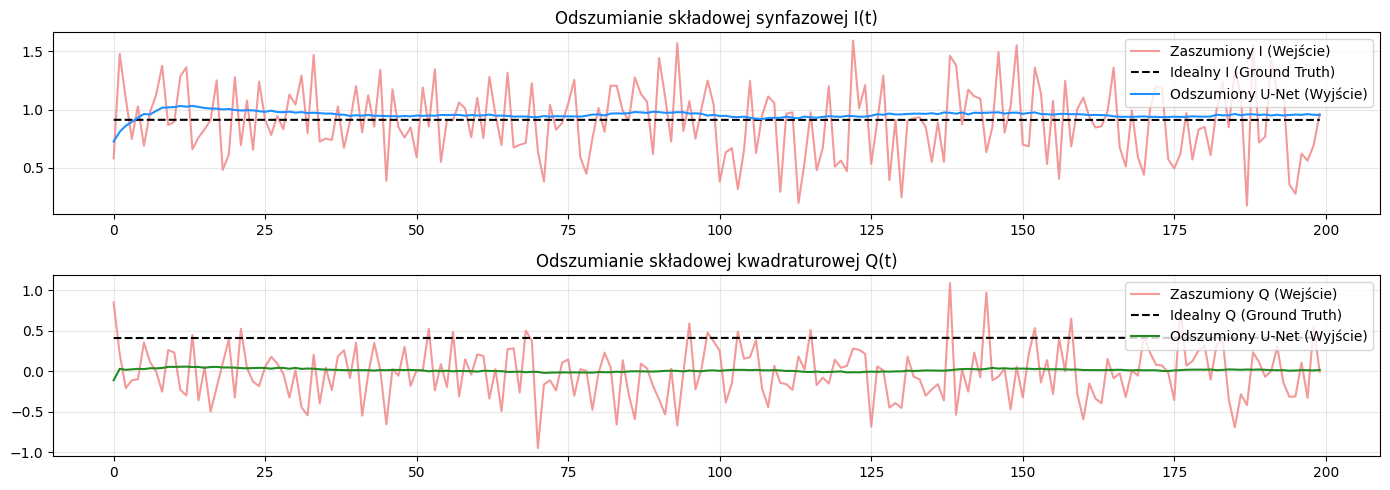

In [7]:
model.eval()
x_test, y_test = next(iter(val_loader))
x_sample, y_sample = x_test[0:1].to(device), y_test[0:1]

with torch.no_grad():
    y_pred = model(x_sample).cpu().numpy()[0]

x_noisy = x_sample.cpu().numpy()[0]
y_true = y_sample.numpy()[0]

plt.figure(figsize=(14, 5))

# Wykres składowej I (In-phase)
plt.subplot(2, 1, 1)
plt.plot(x_noisy[0, :200], label='Zaszumiony I (Wejście)', color='lightcoral', alpha=0.8)
plt.plot(y_true[0, :200], label='Idealny I (Ground Truth)', color='black', linestyle='--')
plt.plot(y_pred[0, :200], label='Odszumiony U-Net (Wyjście)', color='dodgerblue')
plt.title("Odszumianie składowej synfazowej I(t)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Wykres składowej Q (Quadrature)
plt.subplot(2, 1, 2)
plt.plot(x_noisy[1, :200], label='Zaszumiony Q (Wejście)', color='lightcoral', alpha=0.8)
plt.plot(y_true[1, :200], label='Idealny Q (Ground Truth)', color='black', linestyle='--')
plt.plot(y_pred[1, :200], label='Odszumiony U-Net (Wyjście)', color='forestgreen')
plt.title("Odszumianie składowej kwadraturowej Q(t)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()